In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:

df = pd.read_csv('insurance_fraud_data_preprocessed.csv')

selected_features = ['annual_income', 'age_of_driver', 'policy deductible']
X = df[selected_features]
y = df['fraud reported']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = make_pipeline(StandardScaler(), LogisticRegression())
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test) 




In [3]:

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_acc*100:.2f}%")
print(f"Testing Accuracy:  {test_acc*100:.2f}%")
print(f"Gap:               {abs(train_acc - test_acc)*100:.2f}%")
print("-" * 30)

if train_acc > test_acc + 0.10:
    print("OVERFITTING detected.")
elif train_acc < 0.60:
    print("UNDERFITTING detected.")
else:
    print("GOOD FIT.")

print("\n--- DETAILED METRICS (Test Data) ---")
print(classification_report(y_test, y_test_pred))


Training Accuracy: 77.53%
Testing Accuracy:  78.08%
Gap:               0.55%
------------------------------
GOOD FIT.

--- DETAILED METRICS (Test Data) ---
              precision    recall  f1-score   support

           0       0.78      0.99      0.87      1791
           1       0.82      0.13      0.22       577

    accuracy                           0.78      2368
   macro avg       0.80      0.56      0.55      2368
weighted avg       0.79      0.78      0.71      2368



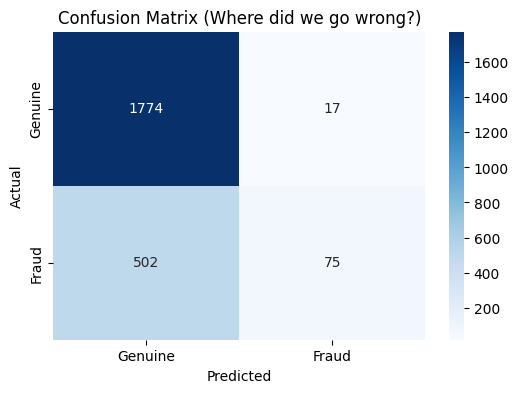

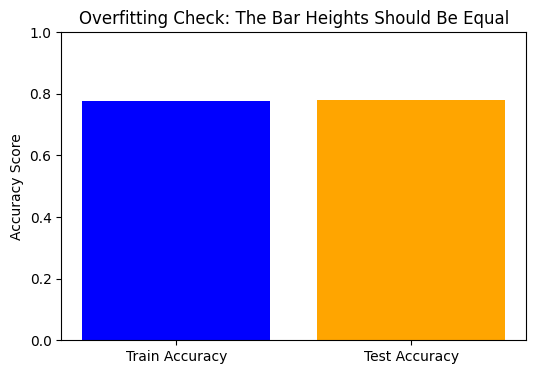

In [4]:

plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Genuine', 'Fraud'], 
            yticklabels=['Genuine', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Where did we go wrong?)')
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(['Train Accuracy', 'Test Accuracy'], [train_acc, test_acc], color=['blue', 'orange'])
plt.ylim(0, 1)
plt.title('Overfitting Check: The Bar Heights Should Be Equal')
plt.ylabel('Accuracy Score')
plt.show()